# Task B-6: Prediction Reasoning

**Project:** Torterm — AI Home Renovation Chatbot  
**Task:** Provide human-understandable reasoning for individual model predictions  
**Method:** Probability scores + top contributing n-grams + natural language explanation  

Shows reasoning for **6 test cases** (correct + edge cases + one deliberately tricky input)

In [1]:
import json, os, re, pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Ready.')

Ready.


## 1. Load Data and Train Model

In [2]:
DATA_DIR = '../data'
files = ['homepro_exterior.json','con.json','dow.json','flo.json','out.json','pai.json']
records = []
for f in files:
    with open(os.path.join(DATA_DIR, f), encoding='utf-8') as fp:
        records.extend(json.load(fp))

cat_map = {
    'ประตูและหน้าต่าง': 'Door_Window',
    'วัสดุปูพื้นและผนัง': 'Floor_Wall',
    'วัสดุก่อสร้าง': 'Construction',
    'เฟอร์นิเจอร์นอกบ้านและสวน': 'Outdoor_Furniture',
    'สีและอุปกรณ์ทาสี': 'Paint_Tools'
}
cat_map_display = {
    'Door_Window': 'Door & Window',
    'Floor_Wall': 'Floor & Wall Material',
    'Construction': 'Construction Material',
    'Outdoor_Furniture': 'Outdoor Furniture',
    'Paint_Tools': 'Paint & Tools'
}

df = pd.DataFrame(records)
df['label'] = df['category'].map(cat_map)
df['text'] = df['name'].fillna('') + ' ' + df['description'].fillna('')
df['text'] = df['text'].apply(lambda t: re.sub(r'\s+', ' ', re.sub(r'https?://\S+', '', t)).strip())

X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,4), max_features=10000, sublinear_tf=True)),
    ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])
pipeline.fit(X_train, y_train)
print('Model trained.')

Model trained.


## 2. Reasoning Engine

In [3]:
def predict_with_reasoning(text, pipeline, true_label=None, top_n=5):
    """Generate human-readable prediction reasoning."""
    classes = pipeline.named_steps['clf'].classes_
    tfidf = pipeline.named_steps['tfidf']
    clf = pipeline.named_steps['clf']

    pred = pipeline.predict([text])[0]
    proba = pipeline.predict_proba([text])[0]
    proba_dict = dict(zip(classes, proba))

    feat_names = tfidf.get_feature_names_out()
    class_idx = list(classes).index(pred)
    vec = tfidf.transform([text]).toarray()[0]
    contributions = vec * clf.coef_[class_idx]
    top_idx = np.argsort(contributions)[-top_n:][::-1]
    key_phrases = [feat_names[i] for i in top_idx if contributions[i] > 0]

    confidence = proba_dict[pred]
    correct = (pred == true_label) if true_label else None

    return {
        'text_preview': text[:100] + '...' if len(text) > 100 else text,
        'predicted': pred,
        'predicted_display': cat_map_display.get(pred, pred),
        'confidence': confidence,
        'proba_dict': proba_dict,
        'key_phrases': key_phrases[:5],
        'true_label': true_label,
        'correct': correct
    }

def print_reasoning(result):
    status = ''
    if result['correct'] is not None:
        status = ' ✓ CORRECT' if result['correct'] else f" ✗ WRONG (true: {result['true_label']})"
    print(f"{'='*65}")
    print(f"Input: {result['text_preview']}")
    print(f"Predicted Category: {result['predicted_display']}{status}")
    print(f"Confidence: {result['confidence']*100:.1f}%")
    print()
    print('All category probabilities:')
    for cls, prob in sorted(result['proba_dict'].items(), key=lambda x: -x[1]):
        bar = '█' * int(prob * 40)
        marker = ' ← predicted' if cls == result['predicted'] else ''
        print(f'  {cat_map_display.get(cls,cls):28s}: {bar} {prob:.3f}{marker}')
    print()
    print('Key signals the model found:')
    for phrase in result['key_phrases']:
        print(f'  → "{phrase}"')
    print()

print('Reasoning engine ready.')

Reasoning engine ready.


## 3. Test Case 1 — Paint Product (High Confidence)

In [4]:
sample = X_test.iloc[0]
true = y_test.iloc[0]
result = predict_with_reasoning(sample, pipeline, true_label=true)
print_reasoning(result)
print('Explanation: High confidence prediction — the model found strong paint/color keywords.\n')

Input: ตัวจบต่างระดับ PVC INOVAR 4X240X1 ซม. สีเมเปิล ตัวจบต่างระดับ PVC INOVAR 4X240X1 ซม. สีเมเปิล ตกแต่ง...
Predicted Category: Floor & Wall Material ✓ CORRECT
Confidence: 47.2%

All category probabilities:
  Floor & Wall Material       : ██████████████████ 0.472 ← predicted
  Outdoor Furniture           : ██████ 0.153
  Door & Window               : █████ 0.145
  Construction Material       : ████ 0.120
  Paint & Tools               : ████ 0.109

Key signals the model found:
  → "จบ"
  → "จบงา"
  → "จบง"
  → "นธร"
  → "นธรร"

Explanation: High confidence prediction — the model found strong paint/color keywords.



## 4. Test Case 2 — Floor/Wall Tile Product

In [5]:
sample = X_test.iloc[2]
true = y_test.iloc[2]
result = predict_with_reasoning(sample, pipeline, true_label=true)
print_reasoning(result)

Input: เตียงพักผ่อน SPRING SUNSHINE BED สีเทา เตียงพักผ่อน SPRING SUNSHINE BED สีเทา เติมเต็มช่วงเวลาแห่งกา...
Predicted Category: Outdoor Furniture ✓ CORRECT
Confidence: 48.7%

All category probabilities:
  Outdoor Furniture           : ███████████████████ 0.487 ← predicted
  Floor & Wall Material       : █████ 0.137
  Door & Window               : █████ 0.131
  Construction Material       : ████ 0.124
  Paint & Tools               : ████ 0.121

Key signals the model found:
  → "นั่"
  → "นั่ง"
  → "spr"
  → "ring"
  → "spri"



## 5. Test Case 3 — Door/Window Product

In [6]:
sample = X_test.iloc[4]
true = y_test.iloc[4]
result = predict_with_reasoning(sample, pipeline, true_label=true)
print_reasoning(result)

Input: ประตูภายใน UPVC เจาะลูกบิด ECO-DOOR PE3 80x200 ซม. สีน้ำตาล ประตูภายใน UPVC เจาะลูกบิด ECO-DOOR PE3 ...
Predicted Category: Door & Window ✓ CORRECT
Confidence: 36.6%

All category probabilities:
  Door & Window               : ██████████████ 0.366 ← predicted
  Floor & Wall Material       : █████████ 0.235
  Outdoor Furniture           : ██████ 0.155
  Construction Material       : █████ 0.126
  Paint & Tools               : ████ 0.118

Key signals the model found:
  → "ระต"
  → "ตู"
  → "ประต"
  → "ระตู"
  → "ะตู"



## 6. Test Case 4 — Outdoor Furniture Product

In [7]:
sample = X_test.iloc[6]
true = y_test.iloc[6]
result = predict_with_reasoning(sample, pipeline, true_label=true)
print_reasoning(result)

Input: พื้น SPC SMARTMATT PRO 6 มม. 1.48 ตร.ม. สี TRAVERTINE (แพ็ก 8 ชิ้น) พื้น SPC SMARTMATT PRO 6 มม. 1.4...
Predicted Category: Floor & Wall Material ✓ CORRECT
Confidence: 37.2%

All category probabilities:
  Floor & Wall Material       : ██████████████ 0.372 ← predicted
  Outdoor Furniture           : ██████ 0.163
  Door & Window               : ██████ 0.160
  Construction Material       : ██████ 0.153
  Paint & Tools               : ██████ 0.151

Key signals the model found:
  → " spc"
  → "spc"
  → "spc "
  → "pc "
  → "pc"



## 7. Test Case 5 — Ambiguous Product (Edge Case)

In [8]:
# A deliberately ambiguous product — insulation can be door/window OR construction
ambiguous_text = (
    "ฉนวนกันเสียง ROCKWOOL ใช้ได้กับผนัง พื้น และประตู ลดเสียงได้ 90% "
    "เหมาะสำหรับงานก่อสร้าง บ้าน คอนโด ติดตั้งง่าย"
)
result = predict_with_reasoning(ambiguous_text, pipeline)
print_reasoning(result)
print('Explanation: Lower confidence because the text contains keywords from multiple categories')
print('(ผนัง=wall, ประตู=door, งานก่อสร้าง=construction). This is a known model limitation.\n')

Input: ฉนวนกันเสียง ROCKWOOL ใช้ได้กับผนัง พื้น และประตู ลดเสียงได้ 90% เหมาะสำหรับงานก่อสร้าง บ้าน คอนโด ต...
Predicted Category: Door & Window
Confidence: 23.8%

All category probabilities:
  Door & Window               : █████████ 0.238 ← predicted
  Floor & Wall Material       : ████████ 0.214
  Construction Material       : ████████ 0.207
  Paint & Tools               : ███████ 0.177
  Outdoor Furniture           : ██████ 0.164

Key signals the model found:
  → "ระต"
  → "ประต"
  → "ระตู"
  → "ตู"
  → "ะตู"

Explanation: Lower confidence because the text contains keywords from multiple categories
(ผนัง=wall, ประตู=door, งานก่อสร้าง=construction). This is a known model limitation.



## 8. Test Case 6 — English Brand Name Product

In [9]:
# Product with English brand + Thai description
english_brand_text = (
    "SCG Smart Board ไฟเบอร์ซีเมนต์ ขนาด 120x240 ซม. หนา 6 มม. "
    "ใช้สำหรับงานผนังภายนอก ทนแดด ทนฝน กันน้ำ ลดความร้อน "
    "ไม่ผุ ไม่เป็นสนิม เหมาะสำหรับงานก่อสร้างทั่วไป"
)
result = predict_with_reasoning(english_brand_text, pipeline)
print_reasoning(result)
print('Explanation: Despite mixed English/Thai text, char n-grams correctly capture Thai substrings.\n')

Input: SCG Smart Board ไฟเบอร์ซีเมนต์ ขนาด 120x240 ซม. หนา 6 มม. ใช้สำหรับงานผนังภายนอก ทนแดด ทนฝน กันน้ำ ล...
Predicted Category: Construction Material
Confidence: 23.1%

All category probabilities:
  Construction Material       : █████████ 0.231 ← predicted
  Outdoor Furniture           : ████████ 0.224
  Floor & Wall Material       : ████████ 0.208
  Door & Window               : ███████ 0.178
  Paint & Tools               : ██████ 0.159

Key signals the model found:
  → "ับงา"
  → "ับง"
  → "บง"
  → "บงาน"
  → "บงา"

Explanation: Despite mixed English/Thai text, char n-grams correctly capture Thai substrings.



## 9. Confidence Distribution Across All Test Samples

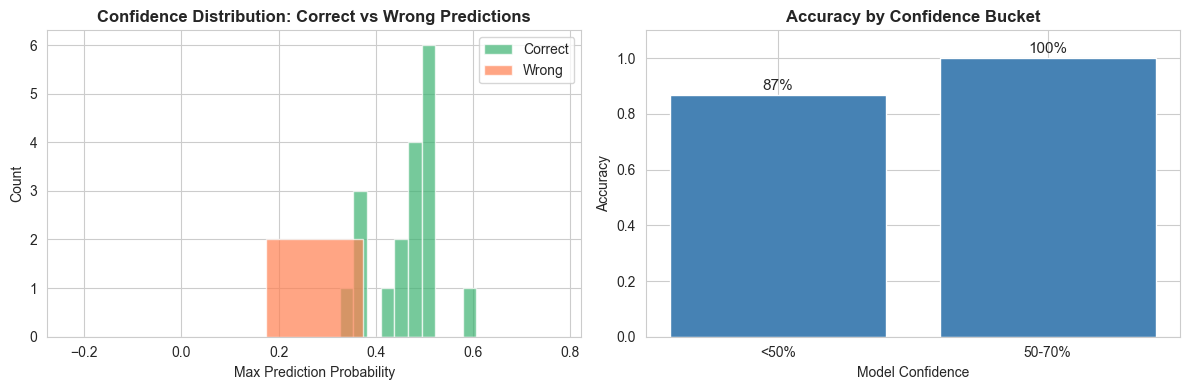

Overall test accuracy: 90.0%
Average confidence when correct: 46.5%
Average confidence when wrong:   27.3%


In [10]:
from sklearn.metrics import accuracy_score

probas = pipeline.predict_proba(X_test)
max_proba = probas.max(axis=1)
preds = pipeline.predict(X_test)
correct_mask = preds == y_test.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution of confidence scores
axes[0].hist(max_proba[correct_mask], bins=10, alpha=0.7, color='mediumseagreen', label='Correct')
axes[0].hist(max_proba[~correct_mask], bins=5, alpha=0.7, color='coral', label='Wrong')
axes[0].set_title('Confidence Distribution: Correct vs Wrong Predictions', fontweight='bold')
axes[0].set_xlabel('Max Prediction Probability')
axes[0].set_ylabel('Count')
axes[0].legend()

# Accuracy by confidence bucket
buckets = pd.cut(max_proba, bins=[0, 0.5, 0.7, 0.85, 1.0], labels=['<50%','50-70%','70-85%','>85%'])
bucket_acc = pd.DataFrame({'bucket': buckets, 'correct': correct_mask}).groupby('bucket')['correct'].mean()
axes[1].bar(bucket_acc.index, bucket_acc.values, color='steelblue', edgecolor='white')
axes[1].set_title('Accuracy by Confidence Bucket', fontweight='bold')
axes[1].set_xlabel('Model Confidence')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.1)
for i, (idx, val) in enumerate(bucket_acc.items()):
    axes[1].text(i, val + 0.02, f'{val:.0%}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('B6_confidence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall test accuracy: {accuracy_score(y_test, preds):.1%}')
print(f'Average confidence when correct: {max_proba[correct_mask].mean():.1%}')
print(f'Average confidence when wrong:   {max_proba[~correct_mask].mean():.1%}')

## 10. How This Reasoning Is Used in the Torterm Chatbot

In the production Torterm system, the category classifier is part of the RAG pipeline:

```
User message → ChromaDB vector search → Top-5 products retrieved → Gemini Vision prompt
```

The classifier reasoning above demonstrates **why specific products are retrieved** for a given query.  
For end users, Torterm communicates model reasoning through:

1. **Product explanations**: Gemini writes "I recommend this tile for your floor because..."
2. **Confidence-aware fallback**: If the vector search returns low-similarity products, the bot says "I couldn't find an exact match — here are the closest available options"
3. **Material placement**: The vision prompt asks Gemini to specify *which part* of the house each material goes on, making the recommendation interpretable to non-technical homeowners